# Water Potability Prediction





**Problem Statement**


Ensuring access to clean drinking water is vital for health, constituting a fundamental human
right and a key element of sound health protection policies. This issue holds significance at the
national, regional, and local levels in terms of both health and development. The objective is to
predict the potability of water based on given features.
The water_potability.csv file contains water quality metrics for 3276 different water bodies

## 1. Import Libraries/Dataset

In [1]:
#Importing the required libaries
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
# Create training and testing sets
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
# Checking accuracy
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV,RepeatedStratifiedKFold
## Ignoring common future deprecation related warning
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')


In [ ]:
# Importing Dataset
data= pd.read_csv('./Dataset.csv')

## 2. Data Visualization and Exploration

In [3]:
# Checking shape
print(data.shape)

(3276, 10)



The data contains 3276 rows and 10 columns

In [4]:
#sanity check
# Viewing the top 2 rows
print(data.head(2))

        ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0      NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.71608  129.422921  18630.057858     6.635246         NaN    592.885359   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  


In [5]:
# Viewing the bottom 2 rows
print(data.tail(2))

            ph    Hardness        Solids  Chloramines  Sulfate  Conductivity  \
3274  5.126763  230.603758  11983.869376     6.303357      NaN    402.883113   
3275  7.874671  195.102299  17404.177061     7.509306      NaN    327.459760   

      Organic_carbon  Trihalomethanes  Turbidity  Potability  
3274       11.168946        77.488213   4.708658           1  
3275       16.140368        78.698446   2.309149           1  


**Features:** 9 features i.e., ph, Hardness,Solids, Chloramines, Sulfate,Conductivity, Organic_carbon, Trihalomethanes, Turbidity

**Target:** 1 i.e., Potability

In [6]:
print(data.describe())

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3114.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162        16.175008     0.780382     0.487849  


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


All Features are of the type float .
The Target is of the type int

0    1998
1    1278
Name: Potability, dtype: int64


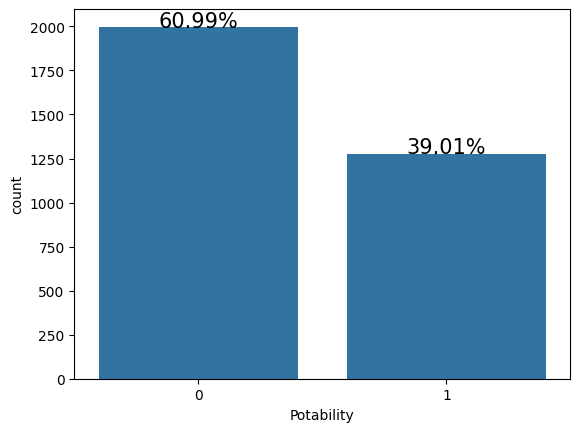

In [8]:
# Checking class imbalance
# Check the how balance is the target
ax=sns.countplot(x='Potability',data=data)
# calculate percents
total = len(data['Potability'])
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center',size=15)
print(data["Potability"].value_counts())
plt.show()

The target distribution shows that 0 was predicted 1998 times i.e., 61% and 1 was predicted 1278 times i.e., 39%



The following class imbalance can be handled by:
*  **Undersampling**: Randomly getting rid of points of the majority class i.e 0, until the classes are balanced
*  **Oversampling**: Increase the representation of the minority classi.e., 1
*  **Class weighting**: At the time of training/modelling give higher weightage to minority class i.e.,1

### c. Provide appropriate data visualizations to get an insight about the dataset.


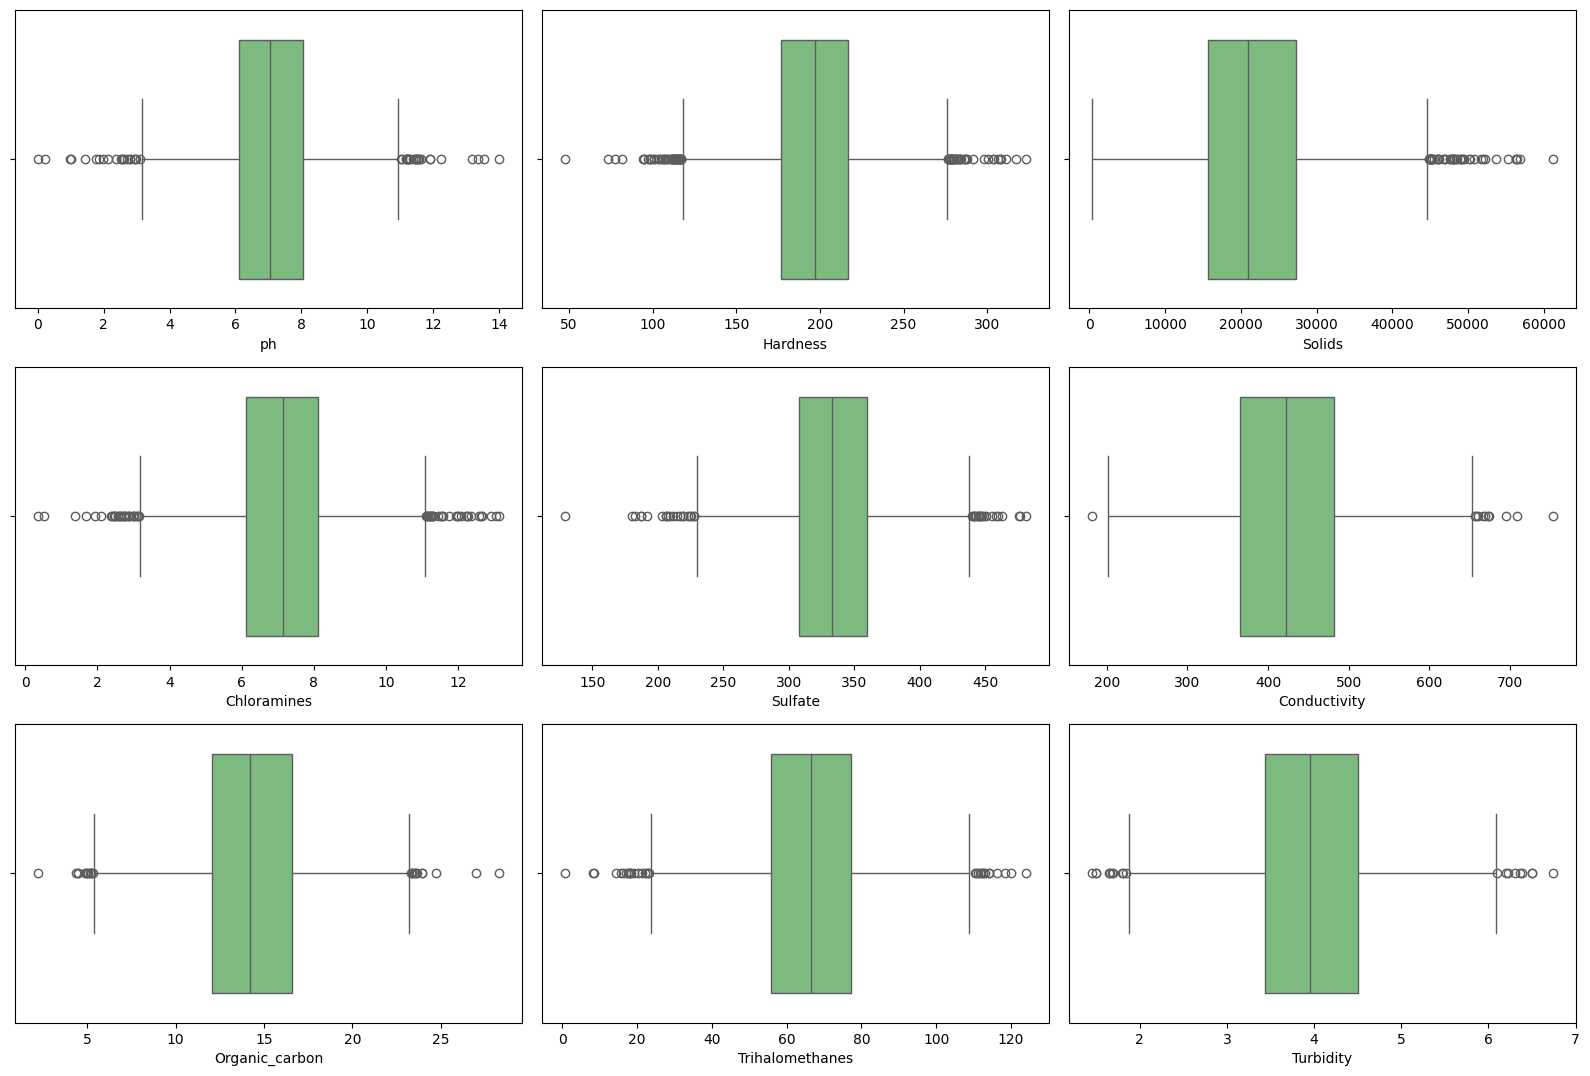

In [10]:
# Visualizing to understand the data
# Checking the outlier
plt.figure(figsize=(16,14))
data_col = data.columns
# Set the color palette
sns.set_palette("Greens")
for i,col in enumerate(data_col[:9]):
    plt.subplot(4,3,i+1)
    #sns.boxplot(data=data[col], palette="Greens")
    #sns.boxplot(x=data[col], palette="Greens", legend=False)
    sns.boxplot(x=data[col], palette="Greens")
    plt.tight_layout()

In the above plots, outliers are observed in the columns where missing values need to be imputed. Therefore, we have chosen the median as the imputation technique to fill missing values.

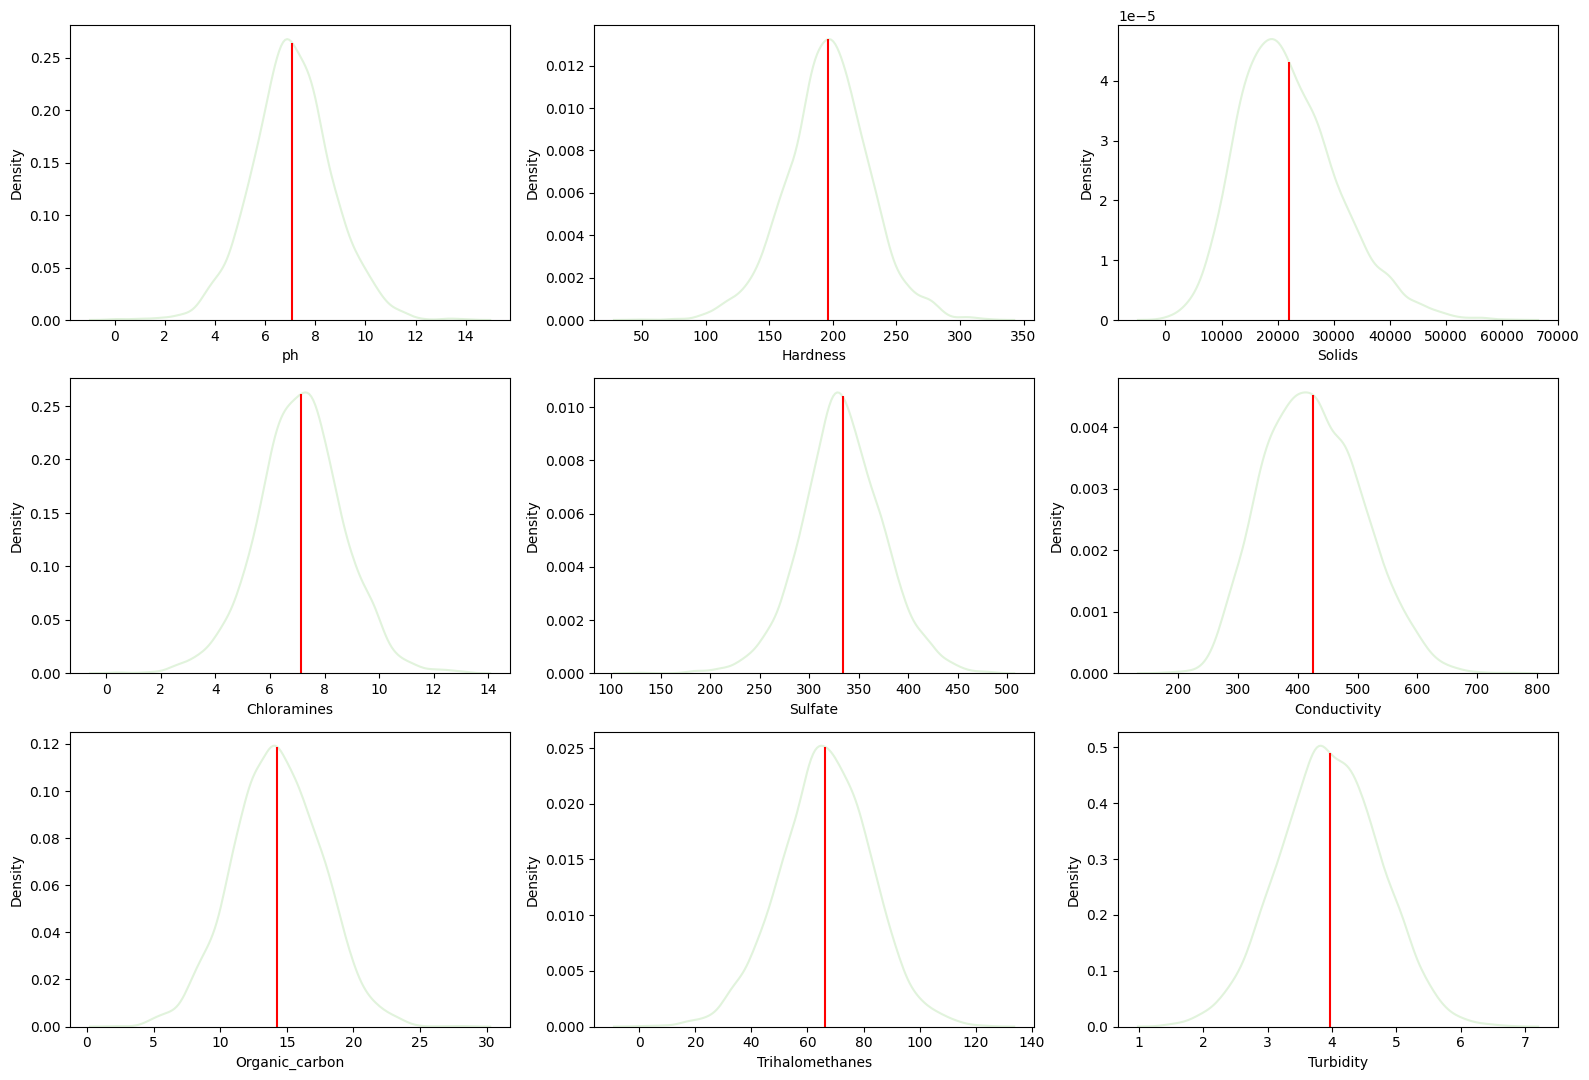

In [11]:
# Checking distribution for all features
plt.figure(figsize=(16,14))
for i,col in enumerate(data_col[:9]):
    plt.subplot(4,3,i+1)
    ax=sns.kdeplot(data=data[col])
    kdeline = ax.lines[0]
    mean = data[col].mean()
    xs = kdeline.get_xdata()
    ys = kdeline.get_ydata()
    height = np.interp(mean, xs, ys)
    ax.vlines(mean, 0, height, color='red', ls='-')
    plt.tight_layout()

In [12]:
skewed = data.skew().sort_values(ascending=False)
skewed

Solids             0.621634
Potability         0.450784
Conductivity       0.264490
ph                 0.025630
Organic_carbon     0.025533
Turbidity         -0.007817
Chloramines       -0.012098
Sulfate           -0.035947
Hardness          -0.039342
Trihalomethanes   -0.083031
dtype: float64

* Features between 0.5 to -0.5 will be considered as the normal distribution i.e., Potability, Conductivity, ph, Organic_carbon,
Turbidity, Chloramines, Sulfate, Hardness, Trihalomethanes
* Skewed feature  is Solids

In [13]:
# Checking the correlation with target
data.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


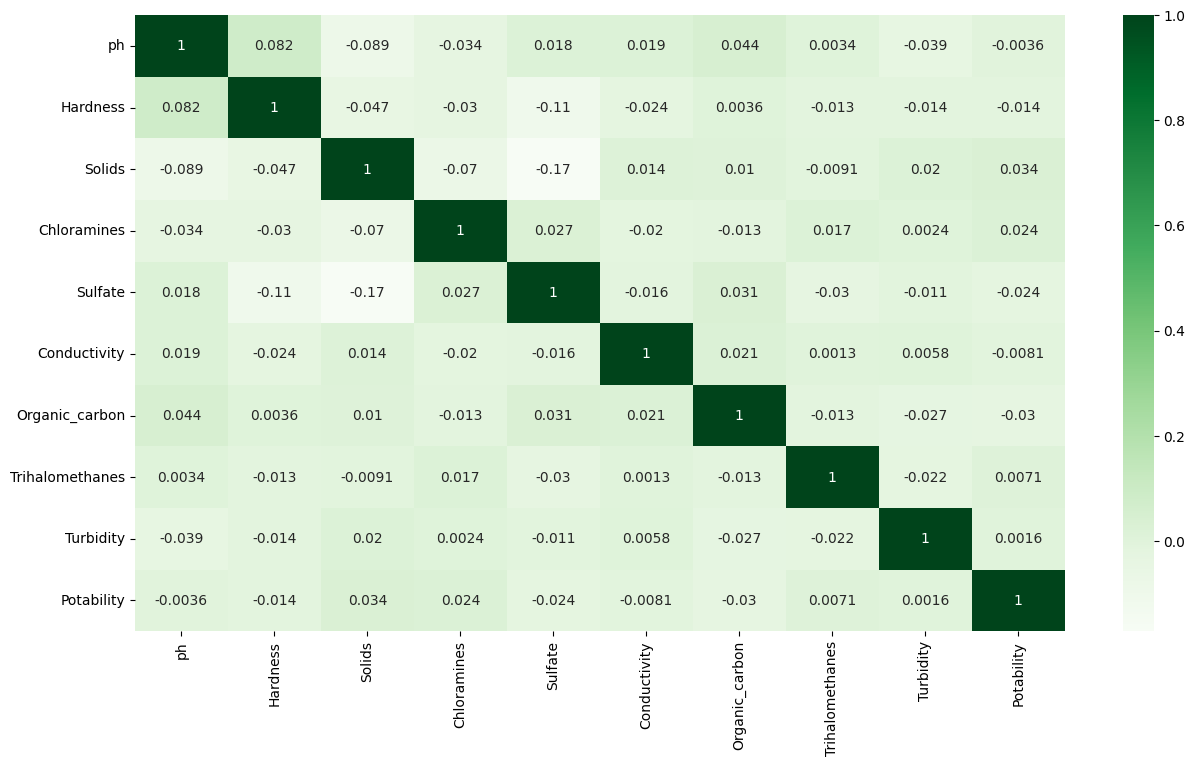

In [14]:
# Visualizing the correlation
plt.figure(figsize=(15,8))
dataplot = sns.heatmap(data.corr(), cmap="Greens", annot=True)

The following features are negatively related to target.Below are the observations.
*   ph - very weak correlation(-0.004)
*   Hardness - very weak correlation(-0.014)
*   Sulfate - weak correlation(-0.024)
*   Conductivity - very weak correlation(-0.008)
*   Organic_carbon - very weak correlation(-0.03)

The following features are positively related to target.Below are the observations.
*   Solids - slight positive correlation(0.034)
*   Chloramies - weak correlation(0.024)
*   Trihalomethness - very weak correlation(0.007)
*   Turbidity - very weak correlation(0.002)

Overall, most of the correlations between the features and potability are very weak, indicating that individual features may not have a strong influence on water potability.


Text(0.5, 1.01, 'Water Potability Pairwise Plots')

<Figure size 1200x600 with 0 Axes>

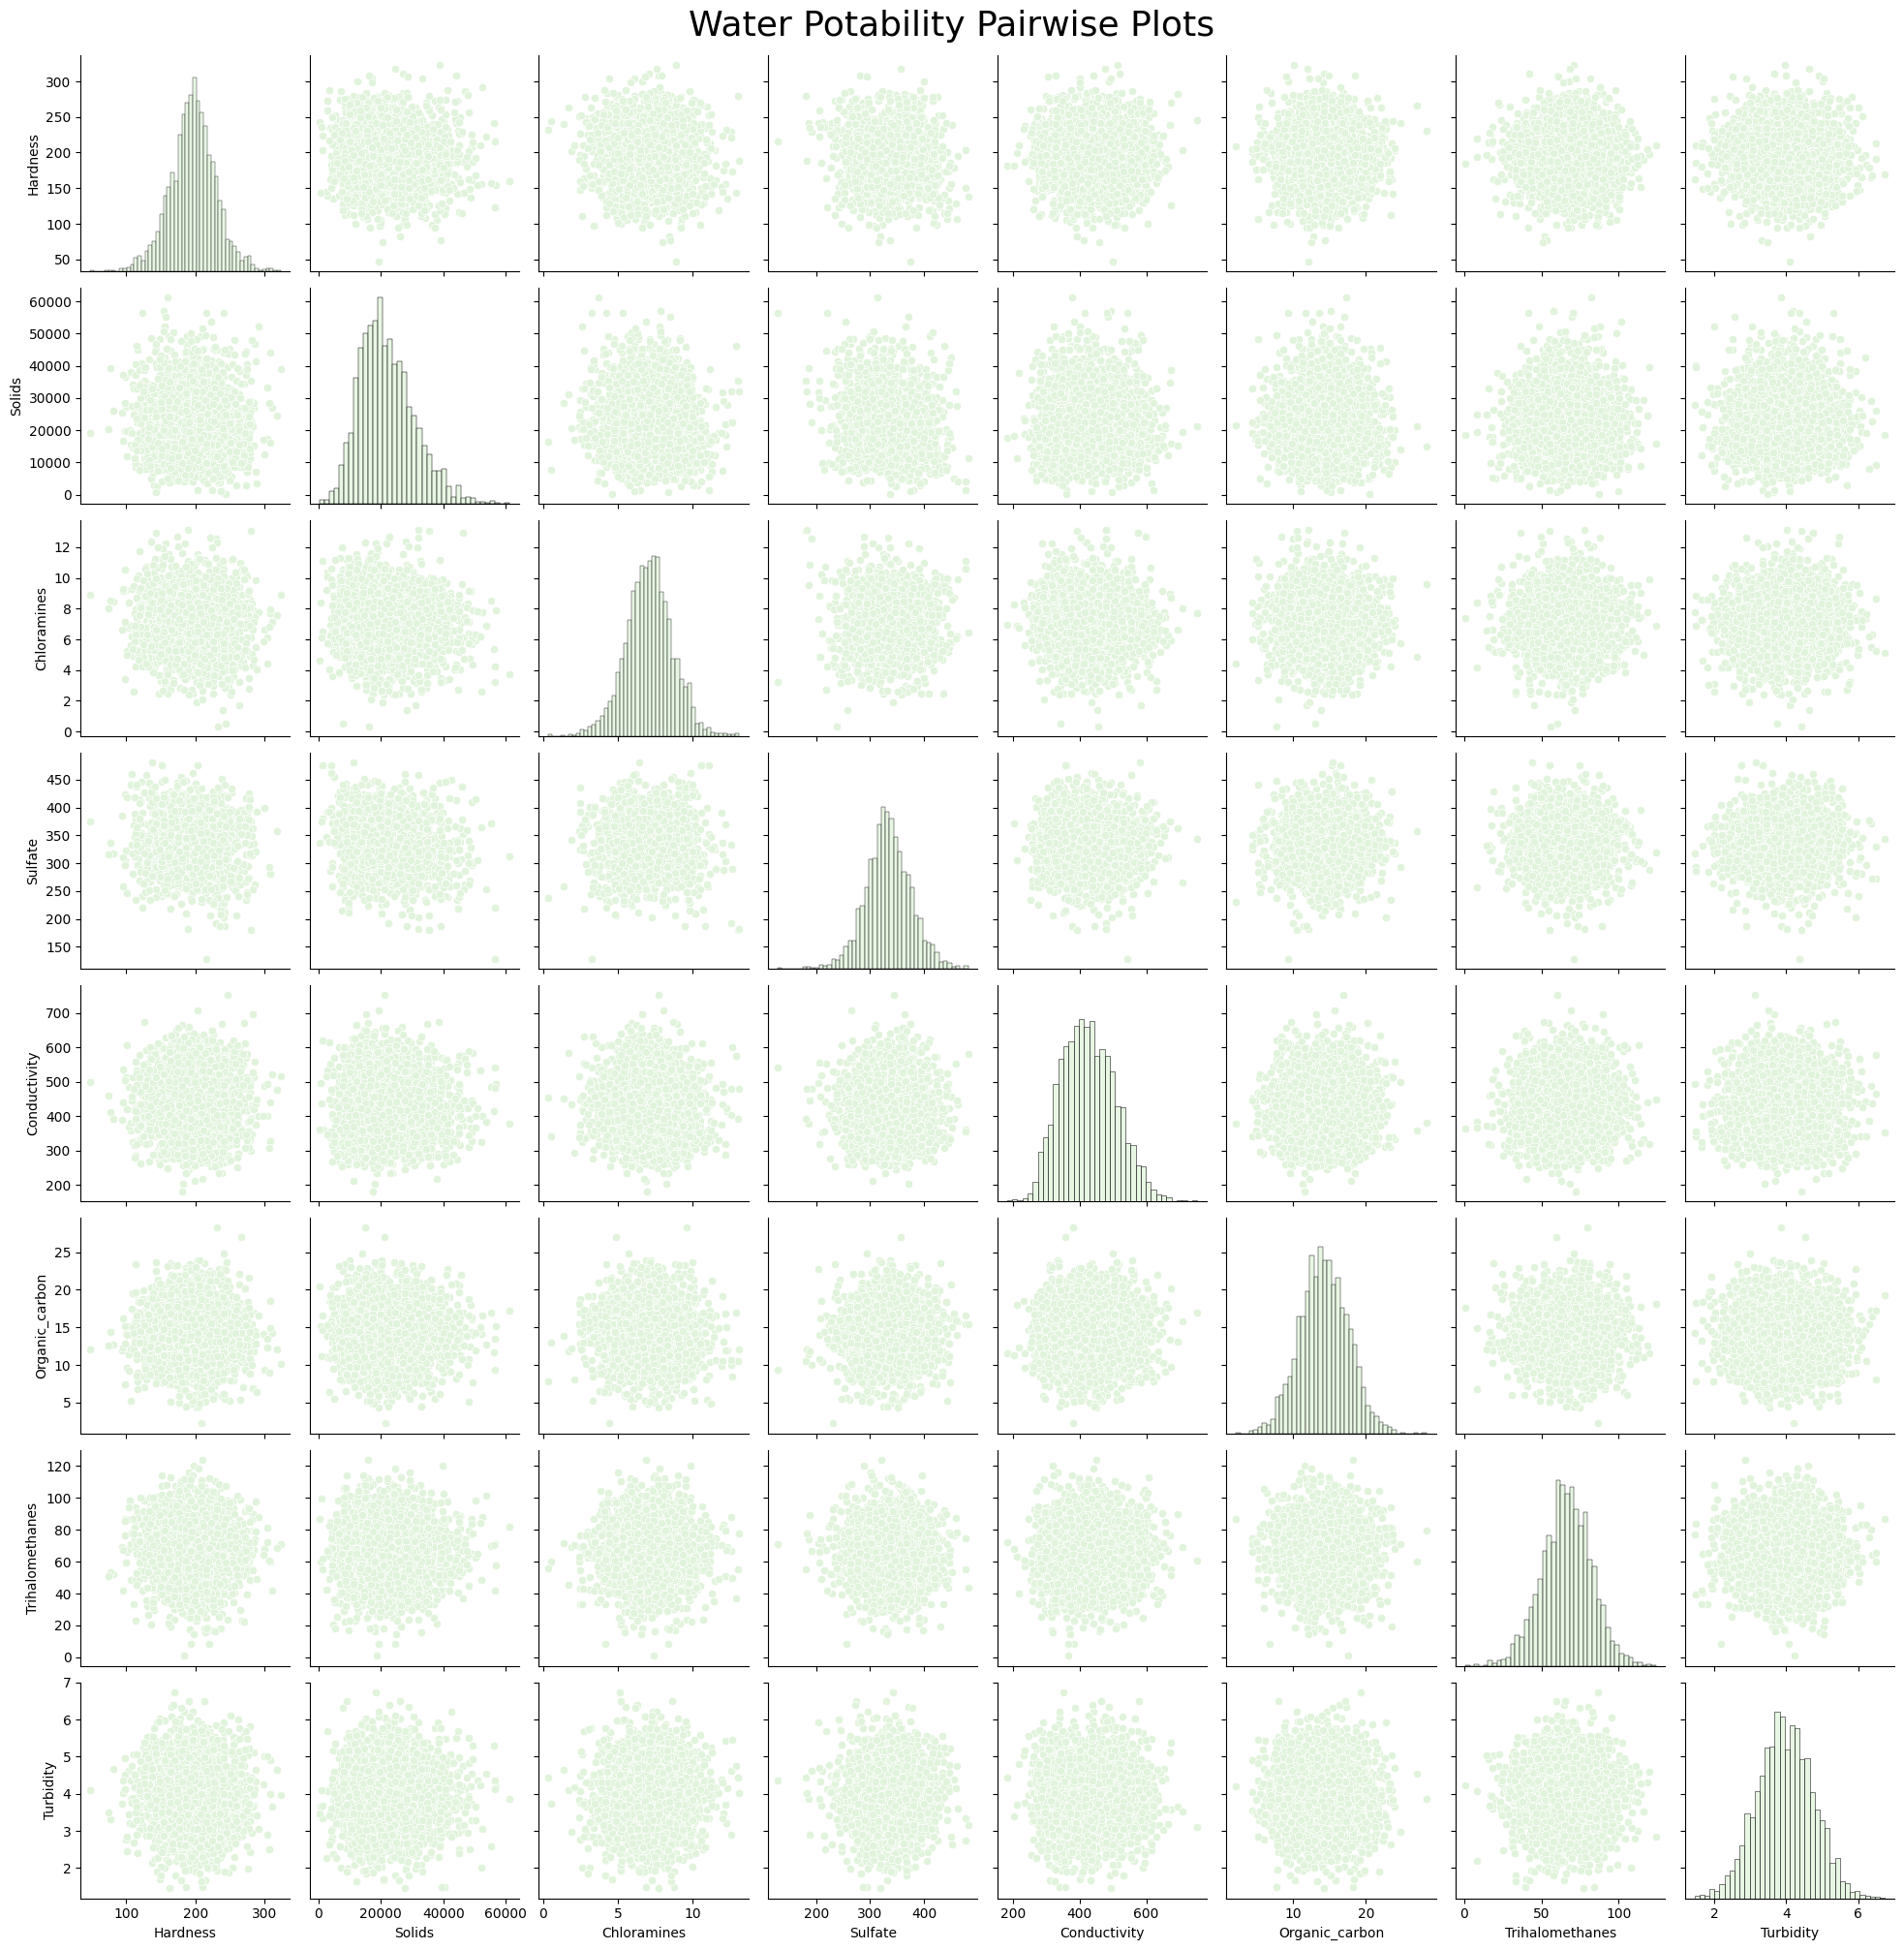

In [15]:
plt.figure(figsize=(12,6))
Pairplot = sns.pairplot(data.iloc[:,1:-1])
Pairplot.fig.suptitle("Water Potability Pairwise Plots",fontsize=26, y=1.01)

*   No of the data points appear to be correlated with each other.
*   Highest correlation being 0.082 i.e., correlation between ph and Hardness

## 3. Data Pre-processing and cleaning

In [16]:
# Checking which columns conatins na values
print(data.isna().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [17]:
# Filling na with median based on previous observation
data['ph'] = data['ph'].fillna(data['ph'].median())
data['Sulfate'] = data['Sulfate'].fillna(data['Sulfate'].median())
data['Trihalomethanes'] = data['Trihalomethanes'].fillna(data['Trihalomethanes'].median())
print(data.isna().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


**Justification for why median technique is been used** :-
The use of the median technique for central tendency estimation is justified due to the presence of outliers in water quality parameters, such as pH, sulfate levels, and Trihalomethanes, which can result from natural variability, contamination events, or measurement errors. By employing the median, we mitigate the undue influence of these outliers, ensuring a more accurate assessment of typical water quality conditions for reliable potability prediction.

In [18]:
X = data[data.columns[:-1]]
Y = data['Potability']

In [19]:
column_data = X.columns.to_list()
scaled_data = pd.DataFrame(columns=column_data)

In [20]:
scaler = MinMaxScaler()
# scaler.fit(X)
# X = scaler.transform(X)
scaled_data[column_data] = scaler.fit_transform(X[column_data])
#scaled_data = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
scaled_data.head()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.502625,0.571139,0.336096,0.543891,0.680385,0.669439,0.313402,0.699753,0.286091
1,0.265434,0.297400,0.300611,0.491839,0.579704,0.719411,0.497319,0.450999,0.576793
2,0.578509,0.641311,0.321619,0.698543,0.579704,0.414652,0.562017,0.532866,0.303637
3,0.594055,0.605536,0.356244,0.603314,0.647347,0.317880,0.622089,0.808065,0.601015
4,0.649445,0.484851,0.289922,0.484900,0.514545,0.379337,0.358555,0.253606,0.496327


**Reason behind choosing MinMaxScaler**

Post analysis on the dataset, we opted to go ahead with **MinMaxScaler** as a scaling technique over StandardScaler because in water probablity dataset we have seen outliers and its features with varying ranges. MinMaxScaler scales features to a fixed range, preserving data distribution and mitigating the impact of outliers, which is crucial in water quality assessment where extreme values may occur. This ensures consistent feature scaling, enhancing model stability and interpretability in predicting water potability.

In [21]:
scaled_data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,0.505300,0.540231,0.356173,0.529963,0.581223,0.427940,0.463026,0.532763,0.475853
std,0.105003,0.119263,0.143968,0.123921,0.102672,0.141336,0.126750,0.127939,0.147548
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.448405,0.469432,0.251957,0.452088,0.534313,0.322196,0.378000,0.453584,0.376198
50%,0.502625,0.542401,0.338338,0.530591,0.579704,0.420386,0.460473,0.534508,0.473630
75%,0.562146,0.613857,0.443498,0.607662,0.628882,0.525145,0.550102,0.615994,0.576729
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Model Building

### Train Test Split

The dataset contains 3276 samples, which is reasonably large.We have splitted the data in below ratio -
> *   Training set: 75%
*   Test set: 25%

1. This split allows the model to learn patterns from the majority of the data while reserving a substantial portion for evaluation, ensuring robust performance assessment.

2. Additionally, setting **random_state=42** ensures reproducibility, facilitating consistent model evaluation across different runs of the code.

In [22]:
# Create training and testing sets
# Check if the number of samples in scaled_data and Y are consistent
if len(scaled_data) != len(Y):
    print("Error: Inconsistent number of samples between scaled_data and Y.")
else:
    # Create training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(scaled_data, Y, test_size=0.25, random_state=42)

    # Print class distribution of target variable in training and testing sets
    print('Target_train: ', Counter(Y_train))
    print('Target_test:', Counter(Y_test))

    # Print list of features
    print('Features:', list(data.columns[0:-1]))


Target_train:  Counter({0: 1488, 1: 969})
Target_test: Counter({0: 510, 1: 309})
Features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


###  Logistic Regression

In [23]:
logistic_regressor_classifier = LogisticRegression(max_iter=100,random_state=0)
# fitting the model for train
logistic_regressor_classifier.fit(X_train,Y_train)
# predicting X train and test
lr_predictions_train = logistic_regressor_classifier.predict(X_train)
lr_predictions_test= logistic_regressor_classifier.predict(X_test)

### Decision Tree

In [24]:
model_dtc = DecisionTreeClassifier( max_depth=4, random_state=42)
model_dtc.fit(X_train,Y_train)
# fitting the model for train
dtc_predictions_test = model_dtc.predict(X_test)
# predicting X train and test
dtc_predictions_train = model_dtc.predict(X_train)

### K-Nearest Neighbors (K-NN)

In [25]:
knn_model = KNeighborsClassifier(n_neighbors=3, weights = 'distance')
knn_model.fit(X_train, Y_train)
# predicting X train and test
knn_predictions_train = knn_model.predict(X_train)
# Make predictions
knn_predictions_test = knn_model.predict(X_test)

### Naive Bayesian

In [26]:
nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)
nb_predictions_train = nb_model.predict(X_train)
# Make predictions
nb_predictions_test = nb_model.predict(X_test)

### Random Forest

In [27]:
rf_model = RandomForestClassifier(n_estimators=5, max_features=1, max_depth=5, random_state=42)
rf_model.fit(X_train, Y_train)

# Make predictions
rf_predictions_train = rf_model.predict(X_train)
rf_predictions_test = rf_model.predict(X_test)

### Adaboost

In [28]:
base_classifier = DecisionTreeClassifier(max_depth=1, random_state=42)
adaboost_model = AdaBoostClassifier(base_classifier, random_state=42)
adaboost_model.fit(X_train, Y_train)
# Make predictions
ab_predictions_train = adaboost_model.predict(X_train)
ab_predictions_test = adaboost_model.predict(X_test)

## 5. Performance Evaluation (Without hyperparameter tuning)

### Logistic Regression

In [29]:
# Checking training accuracy
accuracy_train_lr = round(accuracy_score(Y_train, lr_predictions_train)*100,5)
# Checking test accuracy
accuracy_test_lr = round(accuracy_score(Y_test, lr_predictions_test)*100,5)
print('Accuracy_Training (%) : ',accuracy_train_lr)
print('Accuracy_Test (%) : ' , accuracy_test_lr)
misclass_rate = 100-accuracy_test_lr
print('Misclassification Rate',misclass_rate)

Accuracy_Training (%) :  60.56166
Accuracy_Test (%) :  62.27106
Misclassification Rate 37.72894


<Axes: >

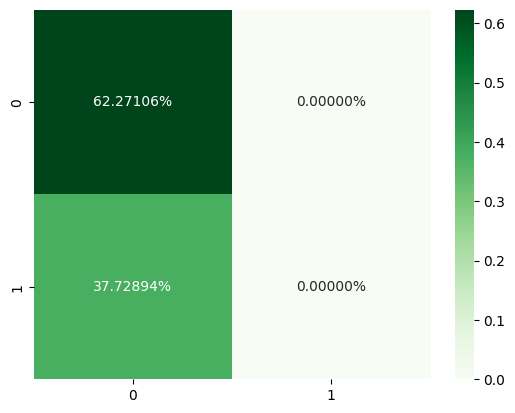

In [30]:
# Checking the confusion matrix
cm_lr = confusion_matrix(Y_test, lr_predictions_test)
# Printing confusion matrix
sns.heatmap(cm_lr/np.sum(cm_lr), annot = True, fmt= '0.5%',cmap="Greens")

### DecisionTreeClassifier

In [31]:
# Checking training accuracy
accuracy_train_dtc = round(accuracy_score(Y_train, dtc_predictions_train)*100,5)
# Checking test accuracy
accuracy_test_dtc = round(accuracy_score(Y_test, dtc_predictions_test)*100,5)
print('Accuracy_Training (%) : ',accuracy_train_dtc)
print('Accuracy_Test (%) : ' , accuracy_test_dtc)
misclass_rate = 100-accuracy_test_dtc
print('Misclassification Rate',misclass_rate)

Accuracy_Training (%) :  64.99796
Accuracy_Test (%) :  63.73626
Misclassification Rate 36.26374


In [32]:
#checking for % of correct prediction and data relevance and mean of both
print(classification_report(Y_test,dtc_predictions_test))

              precision    recall  f1-score   support

           0       0.64      0.96      0.77       510
           1       0.62      0.10      0.18       309

    accuracy                           0.64       819
   macro avg       0.63      0.53      0.47       819
weighted avg       0.63      0.64      0.54       819



<Axes: >

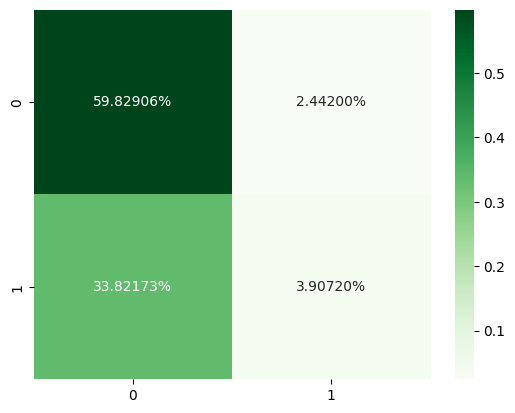

In [33]:
# Checking the confusion matrix
cm_dtc = confusion_matrix(Y_test, dtc_predictions_test)
# Printing confusion matrix
sns.heatmap(cm_dtc/np.sum(cm_dtc), annot = True, fmt= '0.5%',cmap="Greens")

### K-Nearest Neighbors (K-NN)

In [34]:
# Checking training accuracy
accuracy_train_knn = round(accuracy_score(Y_train, knn_predictions_train)*100,5)
# Checking test accuracy
accuracy_test_knn = round(accuracy_score(Y_test, knn_predictions_test)*100,5)
print('Accuracy_Training (%) : ',accuracy_train_knn)
print('Accuracy_Test (%) : ' , accuracy_test_knn)
misclass_rate = 100-accuracy_test_knn
print('Misclassification Rate',misclass_rate)

Accuracy_Training (%) :  100.0
Accuracy_Test (%) :  61.90476
Misclassification Rate 38.09524


In [35]:
#checking for % of correct prediction and data relevance and mean of both
print(classification_report(Y_test,knn_predictions_test))

              precision    recall  f1-score   support

           0       0.68      0.74      0.71       510
           1       0.49      0.42      0.45       309

    accuracy                           0.62       819
   macro avg       0.59      0.58      0.58       819
weighted avg       0.61      0.62      0.61       819



<Axes: >

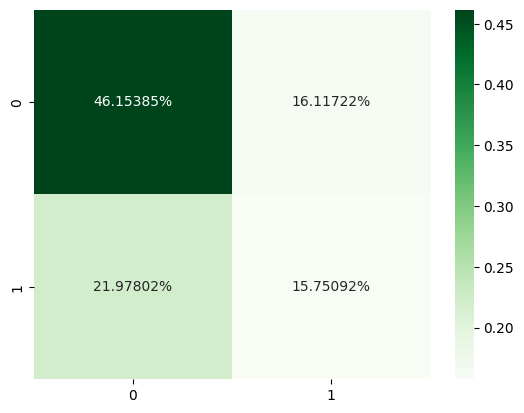

In [36]:
# Checking the confusion matrix
cm_knn = confusion_matrix(Y_test, knn_predictions_test)
# Printing confusion matrix
sns.heatmap(cm_knn/np.sum(cm_knn), annot = True, fmt= '0.5%',cmap="Greens")

### Naive Bayesian

In [37]:
# Checking training accuracy
accuracy_train_nb = round(accuracy_score(Y_train, nb_predictions_train)*100,5)
# Checking test accuracy
accuracy_test_nb = round(accuracy_score(Y_test, nb_predictions_test)*100,5)
print('Accuracy_Training (%) : ',accuracy_train_nb)
print('Accuracy_Test (%) : ' , accuracy_test_nb)
misclass_rate = 100-accuracy_test_nb
print('Misclassification Rate',misclass_rate)

Accuracy_Training (%) :  62.84086
Accuracy_Test (%) :  63.61416
Misclassification Rate 36.38584


In [38]:
print(classification_report(Y_test,nb_predictions_test))

              precision    recall  f1-score   support

           0       0.65      0.89      0.75       510
           1       0.55      0.21      0.31       309

    accuracy                           0.64       819
   macro avg       0.60      0.55      0.53       819
weighted avg       0.61      0.64      0.58       819



<Axes: >

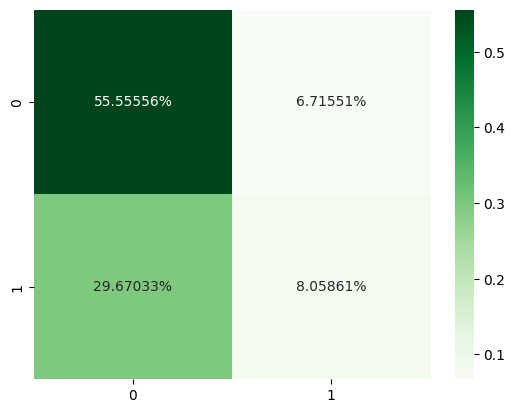

In [39]:
# Checking the confusion matrix
cm_nb = confusion_matrix(Y_test, nb_predictions_test)
# Printing confusion matrix
sns.heatmap(cm_nb/np.sum(cm_nb), annot = True, fmt= '0.5%',cmap="Greens")

### Random Forest

In [40]:
accuracy_train_rf = round(accuracy_score(Y_train, rf_predictions_train)*100,5)
# Checking test accuracy
accuracy_test_rf = round(accuracy_score(Y_test, rf_predictions_test)*100,5)
print('Accuracy_Training (%) : ',accuracy_train_rf)
print('Accuracy_Test (%) : ' , accuracy_test_rf)
misclass_rate = 100-accuracy_test_rf
print('Misclassification Rate',misclass_rate)

Accuracy_Training (%) :  65.40497
Accuracy_Test (%) :  60.43956
Misclassification Rate 39.56044


In [41]:
print(classification_report(Y_test,rf_predictions_test))

              precision    recall  f1-score   support

           0       0.62      0.93      0.75       510
           1       0.36      0.06      0.10       309

    accuracy                           0.60       819
   macro avg       0.49      0.50      0.43       819
weighted avg       0.52      0.60      0.50       819



<Axes: >

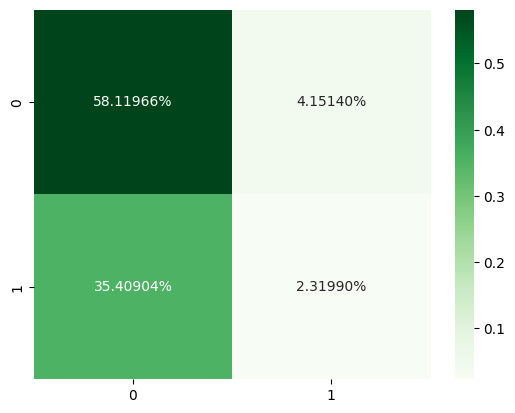

In [42]:
# Checking the confusion matrix
cm_rf = confusion_matrix(Y_test, rf_predictions_test)
# Printing confusion matrix
sns.heatmap(cm_rf/np.sum(cm_rf), annot = True, fmt= '0.5%',cmap="Greens")

### Adaboost

In [43]:
accuracy_train_ab = round(accuracy_score(Y_train, ab_predictions_train)*100,5)
# Checking test accuracy
accuracy_test_ab = round(accuracy_score(Y_test, ab_predictions_test)*100,5)
print('Accuracy_Training (%) : ',accuracy_train_ab)
print('Accuracy_Test (%) : ' , accuracy_test_ab)
misclass_rate = 100-accuracy_test_ab
print('Misclassification Rate',misclass_rate)

Accuracy_Training (%) :  65.85267
Accuracy_Test (%) :  63.73626
Misclassification Rate 36.26374


In [44]:
print(classification_report(Y_test,ab_predictions_test))

              precision    recall  f1-score   support

           0       0.65      0.89      0.75       510
           1       0.55      0.22      0.31       309

    accuracy                           0.64       819
   macro avg       0.60      0.56      0.53       819
weighted avg       0.61      0.64      0.59       819



<Axes: >

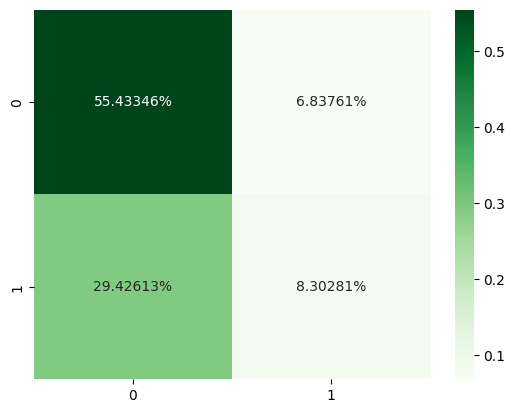

In [45]:
# Checking the confusion matrix
cm_ab = confusion_matrix(Y_test, ab_predictions_test)
# Printing confusion matrix
sns.heatmap(cm_ab/np.sum(cm_ab), annot = True, fmt= '0.5%',cmap="Greens")

## 6. Overall Evaluation (without hyperparameter tuning)

In [46]:
#common function to use for performance evaluation
def evaluation_metrics(model_name, y_test, y_prediction):
  score = {}
  score["model"] = model_name
  score["accuracy"] = round(accuracy_score(y_test, y_prediction),4)
  score["misclassification_rate"]=round(1-score["accuracy"],4)
  score["precision"] = round(precision_score(y_test, y_prediction),4)
  score["recall"] = round(recall_score(y_test, y_prediction),4)
  score["f1_score"] = round(f1_score(y_test, y_prediction),4)

  return score

In [47]:
scores_without_tuning = {}

scores_without_tuning["LR"] = evaluation_metrics("Logistic Regression", Y_test, lr_predictions_test)
scores_without_tuning["DT"] = evaluation_metrics("Decision Tree", Y_test, dtc_predictions_test)
scores_without_tuning["NB"] = evaluation_metrics("Naive Bayesian", Y_test, nb_predictions_test)
scores_without_tuning["KNN"] = evaluation_metrics("K-Nearest Neighbors", Y_test, knn_predictions_test)
scores_without_tuning["AD"] = evaluation_metrics("Adaboost", Y_test, ab_predictions_test)
scores_without_tuning["RF"] = evaluation_metrics("Random Forest", Y_test, rf_predictions_test)

scores_without_tuning_df = pd.DataFrame(scores_without_tuning)
scores_without_tuning_df

,LR,DT,NB,KNN,AD,RF
model,Logistic Regression,Decision Tree,Naive Bayesian,K-Nearest Neighbors,Adaboost,Random Forest
accuracy,0.6227,0.6374,0.6361,0.619,0.6374,0.6044
misclassification_rate,0.3773,0.3626,0.3639,0.381,0.3626,0.3956
precision,0.0,0.6154,0.5455,0.4943,0.5484,0.3585
recall,0.0,0.1036,0.2136,0.4175,0.2201,0.0615
f1_score,0.0,0.1773,0.307,0.4526,0.3141,0.105


Based on models evaluation metrics below is the analysis on where each model is falling under.

*   **Underfitting**: Models suffering from underfitting typically exhibit poor performance across all metrics. In this case, the **Logistic Regression** and **Random Forest** models have very low performance metrics (accuracy, precision, recall, and F1 score). They are too simplistic to capture the complexities of the data, resulting in poor predictive performance.

* **Overfitting**: Overfitting occurs when models perform exceptionally well on the training data but poorly on unseen data. While none of the models demonstrate extremely high accuracy (which could be indicative of overfitting), the **Decision Tree** model might be **slightly** overfitting due to its higher precision compared to recall, especially considering the low F1 score.

* **Just Right**: The models that seem to have a balance between performance metrics are the **Naive Bayesian, K-Nearest Neighbors, and Adaboost** models. They demonstrate moderate to good accuracy, precision, recall, and F1 score. These models are likely performing adequately on the given dataset without exhibiting signs of severe underfitting or overfitting.

## 7. Comparison and Analysis (without hyperparameter tuning)


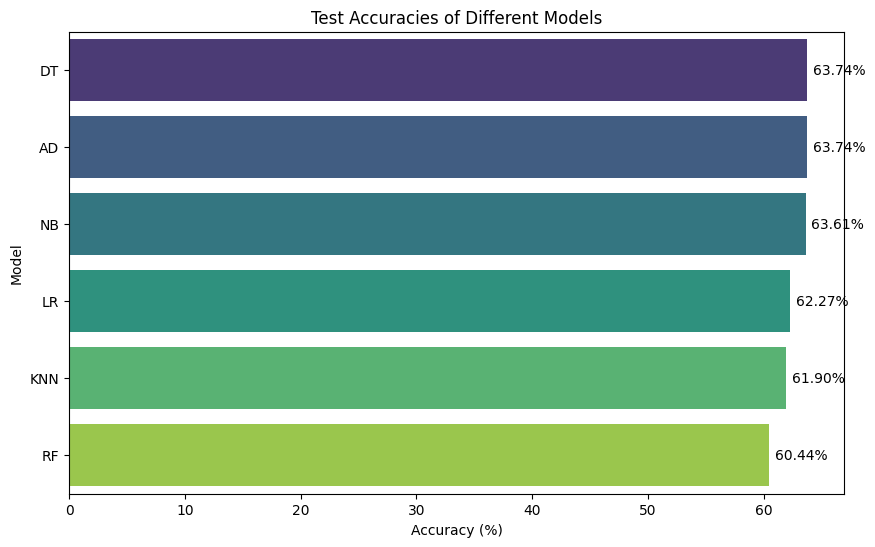

In [48]:
# Extract accuracy values from scores_without_tuning
accuracies = {model: score['accuracy'] * 100 for model, score in scores_without_tuning.items()}

# Create DataFrame from accuracies
df_accuracies = pd.DataFrame.from_dict(accuracies, orient='index', columns=['Accuracy_Test (%)'])
df_accuracies = df_accuracies.sort_values(by='Accuracy_Test (%)', ascending=False)

# Plot barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy_Test (%)', y=df_accuracies.index, data=df_accuracies, palette='viridis')

# Add values on top of bars
for index, value in enumerate(df_accuracies['Accuracy_Test (%)']):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center')


plt.title('Test Accuracies of Different Models')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.show()

Conclusion - Decision Tree, AdaBoost	Algorithm provides near to same level of Accuracy.

## 8. Fine-Tuning Hyperparameters

### Logistic Regression

In [49]:
model=LogisticRegression()
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]
# defining grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search_lr = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_search_lr.fit(X_train, Y_train)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=10, random_state=1),
             error_score=0, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01], 'penalty': ['l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear']},
             scoring='accuracy')

In [50]:
# summarize results
means = grid_search_lr.cv_results_['mean_test_score']
stds = grid_search_lr.cv_results_['std_test_score']
params = grid_search_lr.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

print('===============================================================')
print("Best: %f using %s" % (grid_search_lr.best_score_, grid_search_lr.best_params_))
print("Training Score:",grid_search_lr.score(X_train, Y_train)*100)
print("Testing Score:", grid_search_lr.score(X_test, Y_test)*100)

0.605616 (0.001060) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.605616 (0.001060) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.605616 (0.001060) with: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.605616 (0.001060) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.605616 (0.001060) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.605616 (0.001060) with: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.605616 (0.001060) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.605616 (0.001060) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.605616 (0.001060) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.605616 (0.001060) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.605616 (0.001060) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.605616 (0.001060) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.605616 (0.001060) with: {'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}
0.605616 (0.00106

In [51]:
# predicting X train and test
lr_predictions_train_hpt = grid_search_lr.predict(X_train)
lr_predictions_test_hpt= grid_search_lr.predict(X_test)

### DecisionTreeClassifier

In [52]:
# define models and parameters
model = DecisionTreeClassifier()
criterion = ["gini", "entropy"]
splitter = ["best", "random"]
min_samples_split = [2,4,6,8,10]

# defining grid search
grid = dict(splitter=splitter, criterion=criterion, min_samples_split=min_samples_split)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search_dtc = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_search_dtc.fit(X_train, Y_train)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=10, random_state=1),
             error_score=0, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'min_samples_split': [2, 4, 6, 8, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [53]:
means = grid_search_dtc.cv_results_['mean_test_score']
stds = grid_search_dtc.cv_results_['std_test_score']
params = grid_search_dtc.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.3f} ({stdev:.3f}) with: {param}")

print('===============================================================')
print("Best: %f using %s" % (grid_search_dtc.best_score_, grid_search_lr.best_params_))
print("Training Score:",grid_search_dtc.score(X_train, Y_train)*100)
print("Testing Score:", grid_search_dtc.score(X_test, Y_test)*100)

0.587 (0.029) with: {'criterion': 'gini', 'min_samples_split': 2, 'splitter': 'best'}
0.571 (0.036) with: {'criterion': 'gini', 'min_samples_split': 2, 'splitter': 'random'}
0.591 (0.028) with: {'criterion': 'gini', 'min_samples_split': 4, 'splitter': 'best'}
0.583 (0.029) with: {'criterion': 'gini', 'min_samples_split': 4, 'splitter': 'random'}
0.586 (0.028) with: {'criterion': 'gini', 'min_samples_split': 6, 'splitter': 'best'}
0.586 (0.025) with: {'criterion': 'gini', 'min_samples_split': 6, 'splitter': 'random'}
0.588 (0.023) with: {'criterion': 'gini', 'min_samples_split': 8, 'splitter': 'best'}
0.588 (0.035) with: {'criterion': 'gini', 'min_samples_split': 8, 'splitter': 'random'}
0.592 (0.027) with: {'criterion': 'gini', 'min_samples_split': 10, 'splitter': 'best'}
0.580 (0.034) with: {'criterion': 'gini', 'min_samples_split': 10, 'splitter': 'random'}
0.582 (0.025) with: {'criterion': 'entropy', 'min_samples_split': 2, 'splitter': 'best'}
0.584 (0.036) with: {'criterion': 'entr

In [54]:
# predicting X train and test
dtc_predictions_train_hpt = grid_search_dtc.predict(X_train)
dtc_predictions_test_hpt= grid_search_dtc.predict(X_test)

### K-Nearest Neighbors (K-NN)

In [55]:
model = KNeighborsClassifier()
n_neighbors = range(1, 31)
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

grid = dict(n_neighbors=n_neighbors,weights=weights,metric=metric)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=1)
grid_search_knn = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_search_knn.fit(X_train, Y_train)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=10, random_state=1),
             error_score=0, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 31),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [56]:
means = grid_search_knn.cv_results_['mean_test_score']
stds = grid_search_knn.cv_results_['std_test_score']
params = grid_search_knn.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.3f} ({stdev:.3f}) with: {param}")

print('===============================================================')
print("Best: %f using %s" % (grid_search_knn.best_score_, grid_search_lr.best_params_))
print("Training Score:",grid_search_knn.score(X_train, Y_train)*100)
print("Testing Score:", grid_search_knn.score(X_test, Y_test)*100)

0.582 (0.021) with: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
0.582 (0.021) with: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'distance'}
0.618 (0.023) with: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'uniform'}
0.582 (0.021) with: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'distance'}
0.600 (0.038) with: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
0.600 (0.038) with: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
0.624 (0.022) with: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'uniform'}
0.601 (0.033) with: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'distance'}
0.618 (0.028) with: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
0.617 (0.026) with: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
0.631 (0.025) with: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'uniform'}
0.612 (0.033) with: {'metric': 'euclidean', 'n_neighbors': 6, 'weights'

In [57]:
# predicting X train and test
knn_predictions_train_hpt = grid_search_knn.predict(X_train)
knn_predictions_test_hpt= grid_search_knn.predict(X_test)

### Naive Bayesian


In [58]:
nb_classifier = GaussianNB()

# Define the hyperparameter search space
param_grid = {
    'var_smoothing': [0.00000001, 0.000000001, 0.0000001]
}

grid = dict(n_neighbors=n_neighbors,weights=weights,metric=metric)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=1)
grid_search_nb = GridSearchCV(estimator=nb_classifier, param_grid=param_grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_search_nb.fit(X_train, Y_train)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=10, random_state=1),
             error_score=0, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': [1e-08, 1e-09, 1e-07]},
             scoring='accuracy')

In [59]:
means = grid_search_nb.cv_results_['mean_test_score']
stds = grid_search_nb.cv_results_['std_test_score']
params = grid_search_nb.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print(f"{mean:.3f} ({stdev:.3f}) with: {param}")

print('===============================================================')
print("Best: %f using %s" % (grid_search_nb.best_score_, grid_search_lr.best_params_))
print("Training Score:",grid_search_nb.score(X_train, Y_train)*100)
print("Testing Score:", grid_search_nb.score(X_test, Y_test)*100)

0.618 (0.030) with: {'var_smoothing': 1e-08}
0.618 (0.030) with: {'var_smoothing': 1e-09}
0.618 (0.030) with: {'var_smoothing': 1e-07}
Best: 0.618255 using {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Training Score: 62.84086284086284
Testing Score: 63.61416361416361


In [60]:
# predicting X train and test
nb_predictions_train_hpt = grid_search_nb.predict(X_train)
nb_predictions_test_hpt= grid_search_nb.predict(X_test)

### Random Forest

In [61]:
rf_classifier = RandomForestClassifier(random_state=42)
# Define the hyperparameter search space
param_grid = {
    'n_estimators': np.arange(5, 30, 5),
    'max_depth': np.arange(5, 12, 3),
    'max_features': np.arange(1, 12, 3)
}

rf_grid_search = GridSearchCV(rf_classifier, param_grid=param_grid, cv=3, scoring='recall')
rf_grid_search.fit(X_train, Y_train)

best_rf_n_estimators = rf_grid_search.best_params_['n_estimators']
best_rf_max_depth = rf_grid_search.best_params_['max_depth']
best_rf_max_features = rf_grid_search.best_params_['max_features']
best_rf_model = rf_grid_search.best_estimator_

print(f"Optimal number of trees : { best_rf_n_estimators}")
print(f"Optimal depth of individual trees : { best_rf_max_depth}")
print(f"Optimal max features : { best_rf_max_features}")
rf_predictions_test_hpt = best_rf_model.predict(X_test)

Optimal number of trees : 5
Optimal depth of individual trees : 11
Optimal max features : 10


In [62]:
print(evaluation_metrics("Random Forest tuned", Y_test, rf_predictions_test_hpt))

{'model': 'Random Forest tuned', 'accuracy': 0.6764, 'misclassification_rate': 0.3236, 'precision': 0.6078, 'recall': 0.4013, 'f1_score': 0.4834}


### Adaboost

In [63]:
# Define base classifier
base_classifier = DecisionTreeClassifier(max_depth=2)

# Define AdaBoost model with the base classifier
model_adaboost = AdaBoostClassifier(base_estimator=base_classifier)

# Define parameters for grid search
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.5, 1.0]
algorithm = ['SAMME', 'SAMME.R']

# Define the grid
grid_adaboost = dict(n_estimators=n_estimators, learning_rate=learning_rate, algorithm=algorithm)

# Define cross-validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Define grid search
grid_search_adaboost = GridSearchCV(estimator=model_adaboost, param_grid=grid_adaboost, n_jobs=-1, cv=cv, scoring='accuracy', error_score=0)

# Fit the grid search
grid_search_adaboost.fit(X_train, Y_train)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=10, random_state=1),
             error_score=0,
             estimator=AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2)),
             n_jobs=-1,
             param_grid={'algorithm': ['SAMME', 'SAMME.R'],
                         'learning_rate': [0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [64]:
# Get the results
means_adaboost = grid_search_adaboost.cv_results_['mean_test_score']
stds_adaboost = grid_search_adaboost.cv_results_['std_test_score']
params_adaboost = grid_search_adaboost.cv_results_['params']

# Print results
for mean, stdev, param in zip(means_adaboost, stds_adaboost, params_adaboost):
    print(f"{mean:.3f} ({stdev:.3f}) with: {param}")

print('===============================================================')
print("Best: %f using %s" % (grid_search_adaboost.best_score_, grid_search_adaboost.best_params_))
print("Training Score:", grid_search_adaboost.score(X_train, Y_train) * 100)
print("Testing Score:", grid_search_adaboost.score(X_test, Y_test) * 100)

0.616 (0.011) with: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 50}
0.614 (0.012) with: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 100}
0.615 (0.013) with: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 150}
0.615 (0.015) with: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 50}
0.616 (0.016) with: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 100}
0.616 (0.017) with: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 150}
0.623 (0.021) with: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 50}
0.630 (0.028) with: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 100}
0.624 (0.027) with: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 150}
0.626 (0.017) with: {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 50}
0.624 (0.017) with: {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100}
0.624 (0.020) with: {'algorithm': 'SAMME.R', 'learning

In [65]:
# predicting X train and test
adaboost_predictions_train_hpt = grid_search_adaboost.predict(X_train)
adaboost_predictions_test_hpt= grid_search_adaboost.predict(X_test)

In [66]:
print(evaluation_metrics("Adaboost tuned", Y_test, adaboost_predictions_test_hpt))

{'model': 'Adaboost tuned', 'accuracy': 0.6569, 'misclassification_rate': 0.3431, 'precision': 0.6129, 'recall': 0.246, 'f1_score': 0.351}


## 9. Performance Evaluation (with hyperparameter tuning)

In [67]:
scores_with_tuning = {}

scores_with_tuning["LR-tuned"] = evaluation_metrics("Logistic Regression", Y_test, lr_predictions_test_hpt)
scores_with_tuning["DT-tuned"] = evaluation_metrics("Decision Tree", Y_test, dtc_predictions_test_hpt)
scores_with_tuning["NB-tuned"] = evaluation_metrics("Naive Bayesian", Y_test, nb_predictions_test_hpt)
scores_with_tuning["KNN-tuned"] = evaluation_metrics("K-Nearest Neighbors", Y_test, knn_predictions_test_hpt)
scores_with_tuning["AD-tuned"] = evaluation_metrics("Adaboost", Y_test, adaboost_predictions_test_hpt)
scores_with_tuning["RF-tuned"] = evaluation_metrics("Random Forest", Y_test, rf_predictions_test_hpt)

scores_with_tuning_df = pd.DataFrame(scores_with_tuning)
scores_with_tuning_df

,LR-tuned,DT-tuned,NB-tuned,KNN-tuned,AD-tuned,RF-tuned
model,Logistic Regression,Decision Tree,Naive Bayesian,K-Nearest Neighbors,Adaboost,Random Forest
accuracy,0.6227,0.5983,0.6361,0.6398,0.6569,0.6764
misclassification_rate,0.3773,0.4017,0.3639,0.3602,0.3431,0.3236
precision,0.0,0.4645,0.5455,0.5603,0.6129,0.6078
recall,0.0,0.4239,0.2136,0.2104,0.246,0.4013
f1_score,0.0,0.4433,0.307,0.3059,0.351,0.4834


* **Underfitting**: The **Logistic Regression** (LR-tuned) model still shows very low performance metrics, indicating underfitting. It is unable to capture the patterns in the data effectively, resulting in poor predictive performance.

* **Overfitting**: The **Decision Tree** (DT-tuned) model demonstrates a decrease in accuracy compared to the original Decision Tree model. Although the precision and recall are closer, the drop in accuracy suggests overfitting, as it's performing worse on the test data.

* **Just Right**: The **Naive Bayesian (NB-tuned), K-Nearest Neighbors (KNN-tuned), Adaboost (AD-tuned), and Random Forest (RF-tuned) models** exhibit balanced performance across accuracy, precision, recall, and F1 score. These models have reasonably good accuracy and a balanced trade-off between precision and recall, indicating they might be well-generalized and not suffering from significant underfitting or overfitting.

## 10. Comparison and Analysis (with hyperparameter tuning)


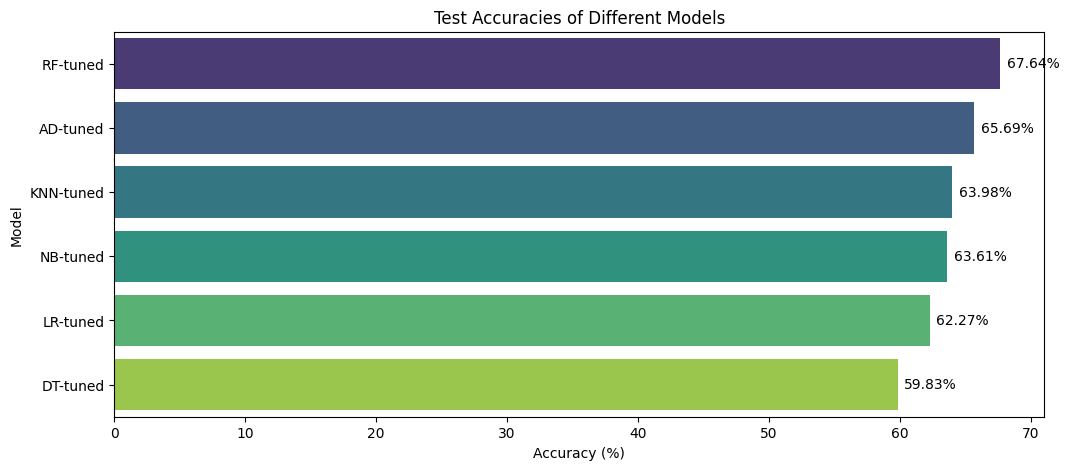

In [68]:
# Extract accuracy values from scores_with_tuning
accuracies = {model: score['accuracy'] * 100 for model, score in scores_with_tuning.items()}

# Create DataFrame from accuracies
df_accuracies = pd.DataFrame.from_dict(accuracies, orient='index', columns=['Accuracy_Test (%)'])
df_accuracies = df_accuracies.sort_values(by='Accuracy_Test (%)', ascending=False)

# Plot barplot
plt.figure(figsize=(12, 5))
sns.barplot(x='Accuracy_Test (%)', y=df_accuracies.index, data=df_accuracies, palette='viridis')

# Add values on top of bars
for index, value in enumerate(df_accuracies['Accuracy_Test (%)']):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center')


plt.title('Test Accuracies of Different Models')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.show()

-

* After hyperparameter tuning, Decision Tree (DT-tuned), K-Nearest Neighbors (KNN-tuned), Adaboost (AD-tuned), and Random Forest (RF-tuned) show improvements in various metrics compared to their untuned counterparts.
* DT-tuned shows a decrease in accuracy but an increase in precision, recall, and F1 score, indicating a better balance between true positives and false positives.
* KNN-tuned demonstrates a slight increase in accuracy and improvements in precision, recall, and F1 score.
* AD-tuned and RF-tuned show significant improvements in accuracy and all other metrics compared to their untuned versions, making them more suitable for the task.

## Model Recommendation:
 Based on the improved performance after hyperparameter tuning, the recommended model is **Random Forest** (RF-tuned) with 67.64%. It achieves the highest accuracy and provides better precision, recall, and F1 score compared to other models, making it the most favorable choice for the given dataset.